In [ ]:
# Import all libraries
from matplotlib import pyplot as plt
import numpy as np

from pathlib import Path
import time
import subprocess

In [ ]:
# Compile and run the code
subprocess.run(["gcc", "-Wall", "-pedantic", "-Wextra", "-O3", "src/main.c", "src/vector/vector.c", "-o", "src/main", "-lm"], check=True)

In [ ]:
# Run the code for each sampling amount
samples_list = [16, 64, 300]
outputs = {}
times = {}

for samples in samples_list:
    output = f"./output_{samples}.csv"
    start = time.perf_counter()
    subprocess.run(
        ["./src/main"],
        input=f"{samples}\n{output}\n", # sample amount and output path of each run
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
        check=True
    )
    times[samples] = time.perf_counter() - start
    outputs[samples] = output

# This generates a .csv output that we can read below

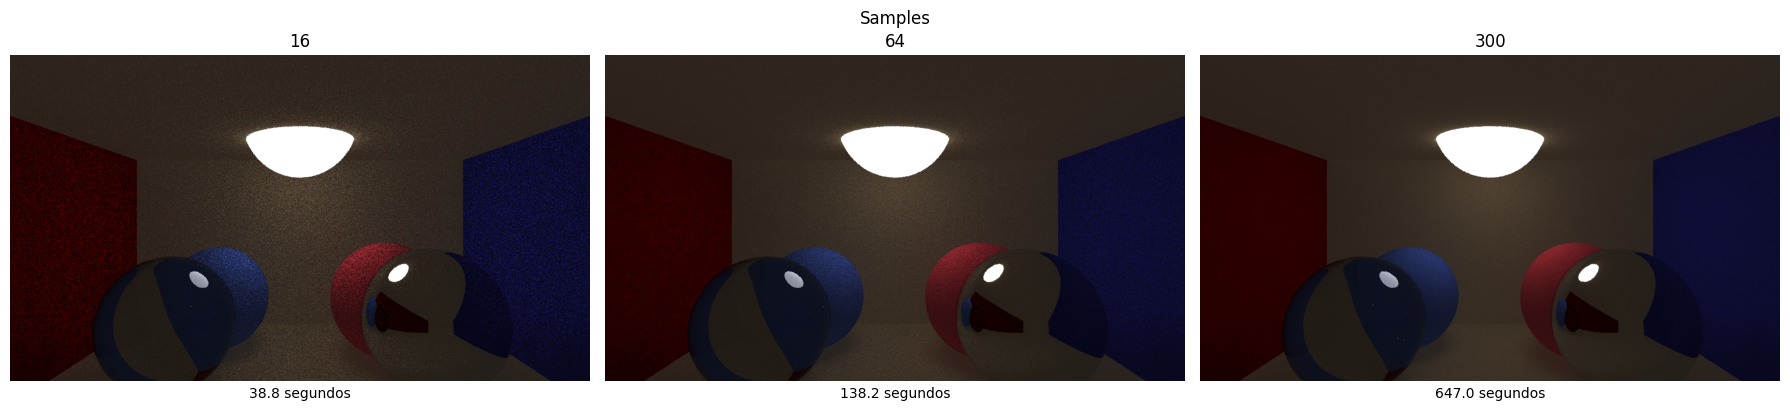

In [ ]:
# Plot the three images
fig, axes = plt.subplots(1, len(samples_list), figsize=(6 * len(samples_list), 4))

for ax, samples in zip(axes, samples_list):
    text = Path(outputs[samples]).read_text()
    numbers = np.array(text.replace("(", " ").replace(")", " ").replace(",", " ").split(), dtype=float)
    viewport = numbers.reshape(720, 1280, 3)

    ax.imshow(viewport, origin="lower")
    ax.set_title(str(samples)) # Show the sampling amount for this image
    ax.set_xlabel(f"{times[samples]:.1f} segundos") # Show the amount of seconds the rendering took
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False) # removes the axis

fig.suptitle("Samples")
plt.tight_layout()
plt.show()